the dataset is of 2024 year and about the earthquakes zones.<br>
The goal of this project is to predict where likely in the world and on what dates the earthquake will happen.


Columns explaination

mag(magnitude of event occured)  
extremely small(<0): very very slight value  
micro(<3.0): felt by few people, detect mainly by instrument  
minor(3.0-3.9): felt by some people, no damaged  
light(4.0-4.9):felt by most people, window may be broken  
moderate(5.0-5.9):felt by most people, damage slightly to poorly built structure  
strong(6.0-6.9): damaged to populated are  
major(7.0-7.9):damaged to major area  
geat(>8.0):devastating  


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

import seaborn as sns 

In [2]:
filepath='all_month_2024.csv'
df=pd.read_csv(filepath)

In [3]:
print('the dataset shape is :',df.shape)


the dataset shape is : (9451, 22)


In [4]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2024-01-26T04:52:42.967Z,31.604000,-104.213000,4.4198,1.7,ml,18.0,69.0,0.100000,0.50,...,2024-01-26T05:08:27.774Z,"51 km NW of Toyah, Texas",earthquake,0.00,1.292059,0.10,13.0,automatic,tx,tx
1,2024-01-26T04:42:50.711Z,64.501000,-146.905800,4.2000,1.4,ml,NaN,NaN,NaN,0.75,...,2024-01-26T05:01:12.516Z,"2 km S of Salcha, Alaska",earthquake,NaN,0.200000,NaN,NaN,automatic,ak,ak
2,2024-01-26T04:32:51.471Z,63.529000,-147.554300,13.1000,1.6,ml,NaN,NaN,NaN,0.62,...,2024-01-26T04:34:54.160Z,"71 km ESE of Denali Park, Alaska",earthquake,NaN,0.300000,NaN,NaN,automatic,ak,ak
3,2024-01-26T04:29:01.180Z,38.833168,-122.797165,1.7300,0.4,md,9.0,65.0,0.007468,0.02,...,2024-01-26T04:46:12.828Z,"6 km W of Cobb, CA",earthquake,0.34,0.970000,0.31,10.0,automatic,nc,nc
4,2024-01-26T04:23:14.444Z,63.546200,-150.971900,0.0000,1.2,ml,NaN,NaN,NaN,0.80,...,2024-01-26T04:25:43.831Z,"37 km E of Denali National Park, Alaska",earthquake,NaN,0.400000,NaN,NaN,automatic,ak,ak


In [5]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9451 entries, 0 to 9450
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             9451 non-null   object 
 1   latitude         9451 non-null   float64
 2   longitude        9451 non-null   float64
 3   depth            9451 non-null   float64
 4   mag              9451 non-null   float64
 5   magType          9451 non-null   object 
 6   nst              7319 non-null   float64
 7   gap              7319 non-null   float64
 8   dmin             6175 non-null   float64
 9   rms              9451 non-null   float64
 10  net              9451 non-null   object 
 11  id               9451 non-null   object 
 12  updated          9451 non-null   object 
 13  place            9451 non-null   object 
 14  type             9451 non-null   object 
 15  horizontalError  6462 non-null   float64
 16  depthError       9451 non-null   float64
 17  magError      

In [6]:
#column names 
print(df.columns.to_list())

['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


In [7]:
#statistical summary
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,9451.000000,9451.000000,9451.000000,9451.000000,7319.000000,7319.000000,6175.000000,9451.000000,6462.000000,9451.000000,7294.000000,7318.000000
mean,39.946558,-110.580238,21.358118,1.631121,24.756797,107.377383,0.590237,0.290898,2.168885,2.113351,0.242064,16.629954
std,18.996832,68.764250,50.809672,1.238299,23.296258,61.486403,2.178746,0.281351,32.909715,9.483877,0.369678,28.370906
min,-65.436500,-179.968700,-3.170000,-1.270000,3.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.417833,-149.698400,2.816150,0.860000,10.000000,64.000000,0.012335,0.100000,0.260000,0.400000,0.110000,6.000000
50%,38.817333,-122.447500,7.250000,1.400000,18.000000,89.910000,0.059530,0.177100,0.460000,0.720000,0.173000,11.000000
75%,56.647900,-112.604333,14.300000,2.000000,32.000000,136.000000,0.146500,0.460000,1.012539,1.500000,0.240000,19.000000
max,86.513000,179.996600,660.826000,7.500000,598.000000,357.000000,40.062000,2.930000,2626.244209,494.700000,5.160000,781.000000


In [8]:
#conerting time to date timee
df['time']=pd.to_datetime(df['time'])

#extracting day as string
df['day']=df['time'].dt.strftime('%Y-%m-%d')

data quality check

In [9]:
df.isnull()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,day
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,True,False,...,False,False,True,False,True,True,False,False,False,False
2,False,False,False,False,False,False,True,True,True,False,...,False,False,True,False,True,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,True,True,False,...,False,False,True,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9446,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9447,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9448,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9449,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               0
nst                2132
gap                2132
dmin               3276
rms                   0
net                   0
id                    0
updated               0
place                 0
type                  0
horizontalError    2989
depthError            0
magError           2157
magNst             2133
status                0
locationSource        0
magSource             0
day                   0
dtype: int64

from the above output we can conclude that the columns - nst , gap , dmin , horizontaleror ,mag error , magnst has a lot of null values in them 

In [11]:
#handling the missing values

#filling the nst missing values with 1
df['nst']=df['nst'].fillna(1)

df.isnull().sum()

time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               0
nst                   0
gap                2132
dmin               3276
rms                   0
net                   0
id                    0
updated               0
place                 0
type                  0
horizontalError    2989
depthError            0
magError           2157
magNst             2133
status                0
locationSource        0
magSource             0
day                   0
dtype: int64

In [12]:
df['magType'].value_counts()


magType
ml       6092
md       2421
mb        800
mww        87
mwr        29
mb_lg      10
mw          6
mh          5
mlv         1
Name: count, dtype: int64

In [13]:
#checking missing value in gap and dmin to determine the imputation value
missing_summary=df[['gap','dmin']].isnull().sum()

missing_percentage=(df[['gap','dmin']].isnull().mean()*100).round(2)

missing_info=pd.DataFrame({
    'MissingValues':missing_summary,
    'Percentage':missing_percentage
})

print(missing_info)

      MissingValues  Percentage
gap            2132       22.56
dmin           3276       34.66


In [14]:
#comparing between conservative and median imputaion 

#----conservative imputation---
df['gap_conservative']=df['gap'].fillna(360)
df['dmin_conservative']=df['dmin'].fillna(5.0)

#-----median imputaion-----
df['gap_median']=df['gap'].fillna(df['gap'].median())
df['dmin_median']=df['dmin'].fillna(df['dmin'].median())

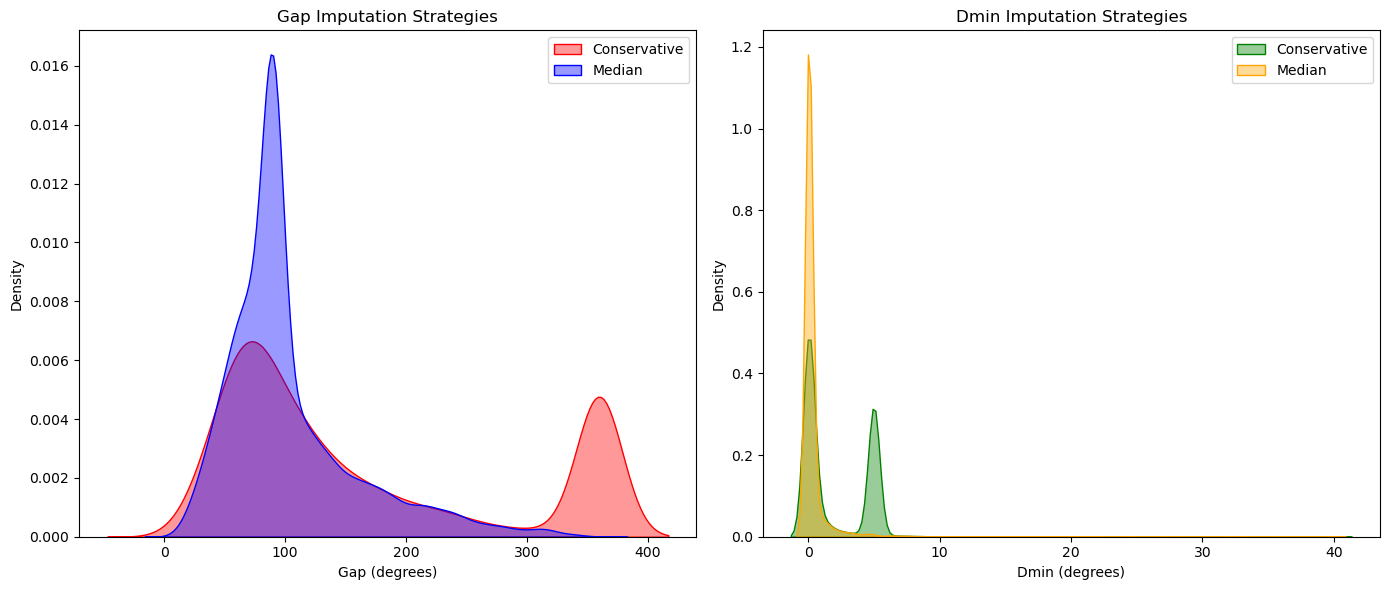

In [15]:
plt.figure(figsize=(14,6))

# --- GAP Comparison ---
plt.subplot(1,2,1)
sns.kdeplot(df['gap_conservative'], label='Conservative', fill=True, color="red", alpha=0.4)
sns.kdeplot(df['gap_median'], label='Median', fill=True, color="blue", alpha=0.4)
plt.title("Gap Imputation Strategies")
plt.xlabel("Gap (degrees)")
plt.ylabel("Density")
plt.legend()

# --- DMIN Comparison ---
plt.subplot(1,2,2)
sns.kdeplot(df['dmin_conservative'], label='Conservative', fill=True, color="green", alpha=0.4)
sns.kdeplot(df['dmin_median'], label='Median', fill=True, color="orange", alpha=0.4)
plt.title("Dmin Imputation Strategies")
plt.xlabel("Dmin (degrees)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
#using median to fill the missing values 
gap_median=df['gap'].median()
dmin_median=df['dmin'].median()

df['gap']=df['gap'].fillna(gap_median)
df['dmin']=df['dmin'].fillna(dmin_median)

print('Median of gap:',gap_median)
print('Median of dmin:',dmin_median)

Median of gap: 89.91
Median of dmin: 0.05953


In [17]:
df.isnull().sum()

time                    0
latitude                0
longitude               0
depth                   0
mag                     0
magType                 0
nst                     0
gap                     0
dmin                    0
rms                     0
net                     0
id                      0
updated                 0
place                   0
type                    0
horizontalError      2989
depthError              0
magError             2157
magNst               2133
status                  0
locationSource          0
magSource               0
day                     0
gap_conservative        0
dmin_conservative       0
gap_median              0
dmin_median             0
dtype: int64

In [18]:
#dropping the unnecessary columns like horizaontal error , magerror and filling the magNst missing values with 1 .

df=df.drop(columns=['horizontalError','magError'])

df['magNst'].fillna(1,inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3252\3239799207.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['magNst'].fillna(1,inplace=True)


In [19]:
df.isnull().sum()

time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                  0
gap                  0
dmin                 0
rms                  0
net                  0
id                   0
updated              0
place                0
type                 0
depthError           0
magNst               0
status               0
locationSource       0
magSource            0
day                  0
gap_conservative     0
dmin_conservative    0
gap_median           0
dmin_median          0
dtype: int64

Now all the missing values are removed/filled and dopped the waste columns <br>
Data Cleaned Succesfully!!!

In [20]:
#count total duplicates 
duplicates_count=df.duplicated().sum()
print(f"Total dupliates rows:{duplicates_count}")

Total dupliates rows:0


Now we are checking if the each column falls in the ideal range 

In [21]:
#for the latitude column the range should be : -90 to 90
# and for the longitude column -180 to 180

print(df['latitude'].describe())
print('-'*20)
print(df['longitude'].describe())

count    9451.000000
mean       39.946558
std        18.996832
min       -65.436500
25%        33.417833
50%        38.817333
75%        56.647900
max        86.513000
Name: latitude, dtype: float64
--------------------
count    9451.000000
mean     -110.580238
std        68.764250
min      -179.968700
25%      -149.698400
50%      -122.447500
75%      -112.604333
max       179.996600
Name: longitude, dtype: float64


In [22]:
invalid_mask = (df['latitude'] < -90) | (df['latitude'] > 90) | (df['longitude'] < -180) | (df['longitude'] > 180)

# Filter invalid rows
invalid_coords = df[invalid_mask]

print(invalid_coords)

Empty DataFrame
Columns: [time, latitude, longitude, depth, mag, magType, nst, gap, dmin, rms, net, id, updated, place, type, depthError, magNst, status, locationSource, magSource, day, gap_conservative, dmin_conservative, gap_median, dmin_median]
Index: []

[0 rows x 25 columns]


there are no invalid cooredinates

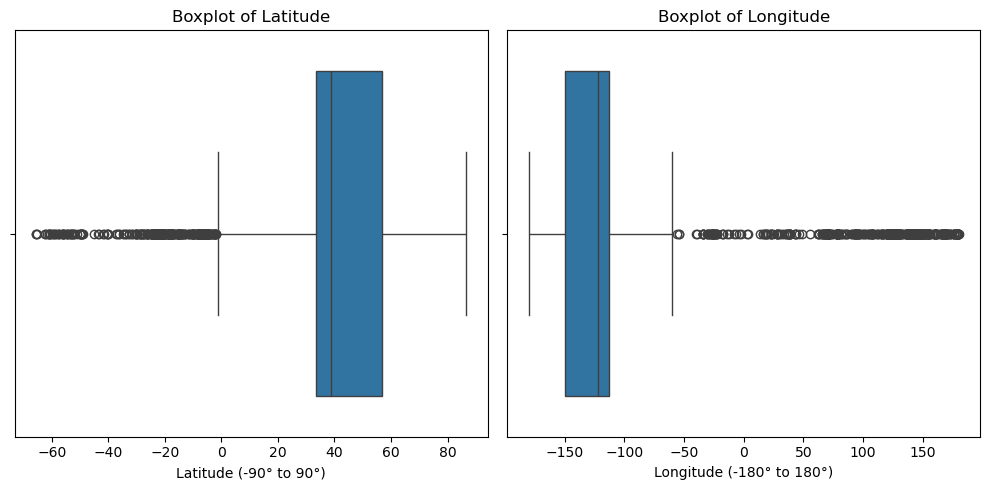

In [23]:
plt.figure(figsize=(10,5))

# Latitude
plt.subplot(1,2,1)
sns.boxplot(x=df['latitude'])
plt.title("Boxplot of Latitude")
plt.xlabel("Latitude (-90° to 90°)")

# Longitude
plt.subplot(1,2,2)
sns.boxplot(x=df['longitude'])
plt.title("Boxplot of Longitude")
plt.xlabel("Longitude (-180° to 180°)")

plt.tight_layout()
plt.show()

In [24]:
#the depth in the dataset should not be less than 0
wrong_depth=df['depth'] < 0
print(f"No. of odd depths in the dataset : {wrong_depth.sum()}")

No. of odd depths in the dataset : 249


In [25]:
df=df[df['depth']>=0].copy() #dropping the odd depths as it is not viable 

In [26]:
print((df['depth']<0).sum())

0


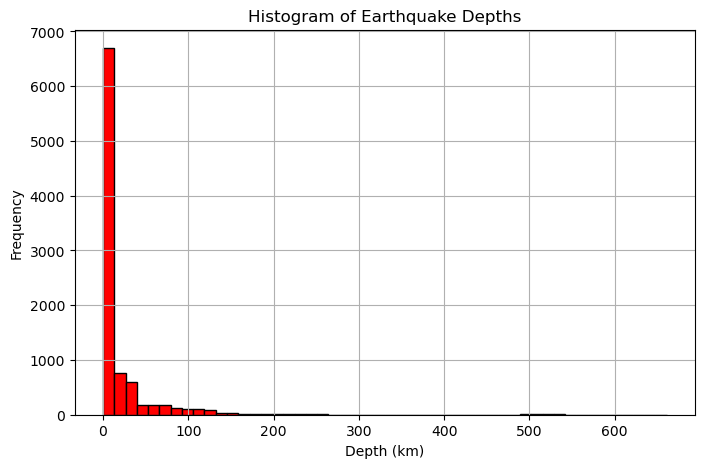

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['depth'], bins=50, color='Red', edgecolor='black')

plt.title("Histogram of Earthquake Depths")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [28]:
#check if any value of magnitude less than or equal to zero
count_nonpositive = (df['mag'] <= 0).sum()

print(f"Number of earthquakes with magnitude <= 0 is {count_nonpositive}")

Number of earthquakes with magnitude <= 0 is 416


In [29]:
df = df[df['mag'] > 0]

print(f"Dataset shape after dropping mag <= 0 is: {df.shape}")

Dataset shape after dropping mag <= 0 is: (8786, 25)


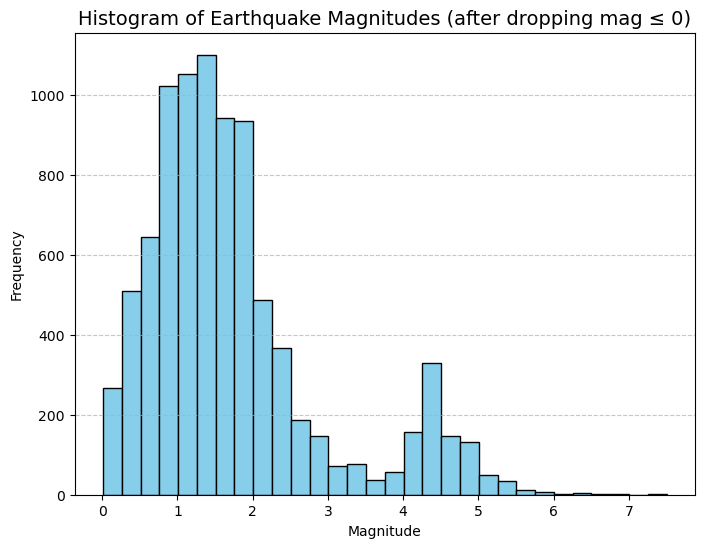

In [30]:
# Plot histogram of magnitudes after cleaning
plt.figure(figsize=(8,6))
plt.hist(df['mag'], bins=30, edgecolor='black', color='skyblue')
plt.title('Histogram of Earthquake Magnitudes (after dropping mag ≤ 0)', fontsize=14)
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


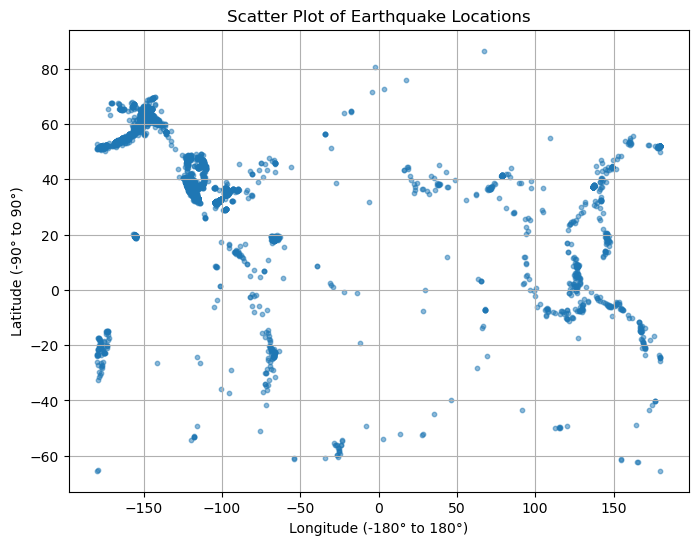

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'], alpha=0.5, s=10)

plt.title("Scatter Plot of Earthquake Locations")
plt.xlabel("Longitude (-180° to 180°)")
plt.ylabel("Latitude (-90° to 90°)")
plt.grid(True)

plt.show()

making different plots for better visualisation!!!

In [32]:
import plotly.express as px

df['day'] = pd.to_datetime(df['time']).dt.strftime('%Y-%m-%d')

fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    color="mag",
    size="mag",
    hover_name="place",
    animation_frame="day", 
    projection="natural earth",
    title="Earthquake Locations and Magnitudes (Daily Animation)",
    color_continuous_scale="Rainbow",
    size_max=15
)

fig.update_layout(height=650)
fig.show()